In [88]:
import numpy as np
import pandas as pd
from pathlib import Path
import re

# ============================================================
# PBL (Prototype / HWCT) from PROTOTYPE daily CSV
#   - Prototype input: 1 wide CSV file (range column + time columns "00.05" ... "23.35")
#   - miniMPL window:  pbls_day CSV with columns: pbls_m, min_pbls_m, max_pbls_m
#   - Output: ONE CSV file per day (results only)
# ============================================================

# ---------- time normalization ----------
def proto_time_to_key(t: str) -> str:
    # "00.05" -> "0005"
    return str(t).strip().replace(".", "").zfill(4)

def extract_hhmm_from_anything(x) -> str:
    """
    Return "HHMM" from many possible time formats, e.g.
      - "0005" -> "0005"
      - "00:05" -> "0005"
      - "000500" -> "0005"
      - "26-01-19 000500" -> "0005"
      - "2026-01-19 00:05:00" -> "0005"
      - pandas Timestamp -> "HHMM"
    """
    if pd.isna(x):
        return ""

    if isinstance(x, (pd.Timestamp,)):
        return f"{x.hour:02d}{x.minute:02d}"

    s = str(x).strip()

    # Try HH:MM or HH.MM
    m = re.search(r"(\d{1,2})[:.](\d{2})", s)
    if m:
        hh = int(m.group(1))
        mm = int(m.group(2))
        if 0 <= hh <= 23 and 0 <= mm <= 59:
            return f"{hh:02d}{mm:02d}"

    # Otherwise, grab LAST numeric group (often HHMM or HHMMSS)
    digits = re.findall(r"\d+", s)
    if not digits:
        return ""

    tail = digits[-1].zfill(4)  # e.g. "000500" or "0035"
    if len(tail) >= 6:  # HHMMSS
        hh = int(tail[:2])
        mm = int(tail[2:4])
        if 0 <= hh <= 23 and 0 <= mm <= 59:
            return f"{hh:02d}{mm:02d}"

    if len(tail) >= 4:  # HHMM
        hh = int(tail[:2])
        mm = int(tail[2:4])
        if 0 <= hh <= 23 and 0 <= mm <= 59:
            return f"{hh:02d}{mm:02d}"

    return ""

def hhmm_to_min(hhmm: str) -> int:
    hhmm = str(hhmm).zfill(4)
    return int(hhmm[:2]) * 60 + int(hhmm[2:])

# ---------- math helpers ----------
def moving_average(x, k: int):
    k = int(k)
    if k % 2 == 0:
        k += 1
    w = np.ones(k) / k
    return np.convolve(np.asarray(x, float), w, mode="same")

def fft_lowpass_fixed_fc(x, dr, fc=0.0125, order=6, pad_frac=0.10):
    x = np.asarray(x, dtype=float)
    n = len(x)

    # fill NaN by interpolation
    if np.isnan(x).any():
        idx = np.arange(n)
        good = ~np.isnan(x)
        if good.sum() < 2:
            return np.full_like(x, np.nan)
        x = np.interp(idx, idx[good], x[good])

    mean_x = float(np.nanmean(x))
    x0 = x - mean_x

    pad = int(max(32, pad_frac * n))
    pad = min(pad, n - 2) if n > 2 else 0

    if pad > 0:
        xpad = np.concatenate([x0[pad:0:-1], x0, x0[-2:-pad-2:-1]])
    else:
        xpad = x0.copy()

    N = len(xpad)
    X = np.fft.rfft(xpad)
    f = np.fft.rfftfreq(N, d=dr)  # cycles/m
    H = 1.0 / np.sqrt(1.0 + (f / fc) ** (2 * order))
    ypad = np.fft.irfft(X * H, n=N)

    y = ypad[pad:pad + n] if pad > 0 else ypad
    return y + mean_x

def hwct_curve(nrb_arr, r, smooth_win=7, tol_m=22.5):
    r = np.asarray(r, dtype=float)
    y = moving_average(np.asarray(nrb_arr, float), smooth_win)

    dr_local = float(np.nanmedian(np.diff(r)))
    m = max(1, int(round(tol_m / dr_local)))  # half-window in bins

    W = np.full_like(y, np.nan, dtype=float)
    for i in range(m, len(y) - m):
        W[i] = np.nanmean(y[i:i + m]) - np.nanmean(y[i - m:i])
    return W

def pick_peak_pos_else_neg(W, r, rmin, rmax):
    r = np.asarray(r, float)
    W = np.asarray(W, float)

    mask = (r >= rmin) & (r <= rmax)
    Wm = W.copy()
    Wm[~mask] = np.nan

    if np.all(np.isnan(Wm)):
        return np.nan, np.nan, "no_data"

    # positive peak if exists
    Wpos = Wm.copy()
    Wpos[Wpos < 0] = np.nan
    if not np.all(np.isnan(Wpos)):
        idx = int(np.nanargmax(Wpos))
        return float(r[idx]), float(Wpos[idx]), "positive"

    # fallback most negative
    Wneg = Wm.copy()
    Wneg[Wneg > 0] = np.nan
    if not np.all(np.isnan(Wneg)):
        idx = int(np.nanargmin(Wneg))
        return float(r[idx]), float(Wneg[idx]), "negative_fallback"

    return np.nan, np.nan, "no_peak"

# ---------- detect range col ----------
def detect_range_col(df: pd.DataFrame) -> str:
    candidates = ["range_m", "Range(m)", "range", "Range", "height_m", "Height(m)", "height"]
    for c in candidates:
        if c in df.columns:
            return c
    return df.columns[0]

# ---------- helper: auto-find miniMPL file for a given day ----------
def find_minimpl_file_for_day(base_dir: Path, day: str) -> Path:
    """
    Find miniMPL window file for this day.
    Accepts any of these patterns:
      pbls_<day>_0005_0035_to_2335.csv
      pbls_<day>_*.csv   (fallback)
    """
    # preferred exact pattern
    exact = base_dir / f"pbls_{day}_0005_0035_to_2335.csv"
    if exact.exists():
        return exact

    # fallback: any pbls file for the day
    hits = sorted(base_dir.glob(f"pbls_{day}_*.csv"))
    if len(hits) == 1:
        return hits[0]
    if len(hits) > 1:
        # choose the longest filename (often contains full range)
        hits = sorted(hits, key=lambda p: len(p.name), reverse=True)
        return hits[0]

    raise FileNotFoundError(f"No miniMPL pbls file found for day={day} in {base_dir}")

# ---------- main ----------
def run_pbl_from_prototype_csv_with_minimpl_window(
    *,
    prototype_csv_path: str,
    minimpl_csv_path: str,
    output_dir: str,
    output_name: str | None = None,
    fc: float = 0.0125,
    fft_order: int = 6,
    pad_frac: float = 0.10,
    smooth_win: int = 7,
    tol_m: float = 22.5,
    verbose: bool = True,
):
    outdir = Path(output_dir)
    outdir.mkdir(parents=True, exist_ok=True)

    # ---- load prototype wide CSV
    # ---- load prototype wide CSV
    proto = pd.read_csv(prototype_csv_path)
    
    # DEBUG: inspect column names (hidden spaces, etc.)
    print("Prototype CSV columns (first 10):")
    print([repr(c) for c in proto.columns[:10]])
    
    # OPTIONAL BUT STRONGLY RECOMMENDED: normalize column names
    proto.columns = proto.columns.astype(str).str.strip()
    
    range_col = detect_range_col(proto)

    proto[range_col] = pd.to_numeric(proto[range_col], errors="coerce")
    r = proto[range_col].to_numpy(float)

    dr = float(np.nanmedian(np.diff(r)))
    rmin_clip = float(np.nanmin(r))
    rmax_clip = float(np.nanmax(r))

    time_cols = [c for c in proto.columns if c != range_col]

    # ---- load miniMPL window CSV
    mpl = pd.read_csv(minimpl_csv_path)

    need = {"pbls_m", "min_pbls_m", "max_pbls_m"}
    missing = [c for c in need if c not in mpl.columns]
    if missing:
        raise ValueError(f"miniMPL CSV missing columns: {missing}. Found: {list(mpl.columns)}")

    # auto-detect time col
    possible_time_cols = ["time", "Time", "timestamp", "Timestamp", "t", "datetime", "DateTime"]
    mpl_time_col = None
    for c in possible_time_cols:
        if c in mpl.columns:
            mpl_time_col = c
            break
    if mpl_time_col is None:
        mpl_time_col = mpl.columns[0]
        if verbose:
            print(f"⚠️ miniMPL time column not found by name, using first column: {mpl_time_col}")

    mpl = mpl.copy()
    mpl["time_key"] = mpl[mpl_time_col].apply(extract_hhmm_from_anything)

    bad = mpl["time_key"].eq("") | mpl["time_key"].isna()
    if bad.any() and verbose:
        print("⚠️ Some miniMPL rows could not parse time_key. Examples:")
        print(mpl.loc[bad, [mpl_time_col]].head(5))

    mpl = mpl.loc[~bad].copy()
    mpl["tmin"] = mpl["time_key"].apply(hhmm_to_min)

    mpl_small = (mpl[["time_key", "tmin", "pbls_m", "min_pbls_m", "max_pbls_m"]]
                 .rename(columns={
                     "pbls_m": "PBL_MPL_m",
                     "min_pbls_m": "rmin",
                     "max_pbls_m": "rmax",
                 })
                 .drop_duplicates(subset=["time_key"], keep="last")
                 .sort_values("tmin")
                 .reset_index(drop=True))

    # ---- prototype meta (time -> minutes)
    meta = pd.DataFrame({
        "prototype_col": time_cols,
        "time_key": [proto_time_to_key(c) for c in time_cols],
    })
    meta["tmin"] = meta["time_key"].apply(hhmm_to_min)
    meta = meta.sort_values("tmin").reset_index(drop=True)

    # nearest match by minutes
    meta2 = pd.merge_asof(
        meta,
        mpl_small[["tmin", "time_key", "PBL_MPL_m", "rmin", "rmax"]].sort_values("tmin"),
        on="tmin",
        direction="nearest",
        suffixes=("", "_mpl"),
    )

    meta2["time_key_mpl"] = meta2.get("time_key_mpl", meta2["time_key"])
    meta2["Time_mapping"] = np.where(meta2["time_key"] == meta2["time_key_mpl"], "exact", "nearest")

    if verbose:
        print("miniMPL time_key sample:", mpl_small["time_key"].head(5).tolist())
        print("prototype time_key sample:", meta2["time_key"].head(5).tolist())
        print("mapping counts:", meta2["Time_mapping"].value_counts(dropna=False).to_dict())

    # ---- run pipeline per profile
    rows = []
    for _, m in meta2.iterrows():
        col = m["prototype_col"]
        time_key = m["time_key"]

        y = pd.to_numeric(proto[col], errors="coerce").to_numpy(float)

        if pd.isna(m["rmin"]) or pd.isna(m["rmax"]) or pd.isna(m["PBL_MPL_m"]):
            rows.append({
                "time_key": time_key,
                "prototype_col": col,
                "Time_mapping": m["Time_mapping"],
                "time_key_mpl": m["time_key_mpl"],
                "PBL_MPL_m": np.nan,
                "rmin_m": np.nan,
                "rmax_m": np.nan,
                "PBL_Prototype_m": np.nan,
                "Chosen_mode": "missing_window",
                "HWCT_peak_chosen": np.nan,
                "Delta_Prototype_minus_MPL_m": np.nan,
                "NRB_all_nan": bool(np.all(np.isnan(y))),
            })
            continue

        rmin_use = max(float(m["rmin"]), rmin_clip)
        rmax_use = min(float(m["rmax"]), rmax_clip)
        pbl_mpl = float(m["PBL_MPL_m"])

        y_dn = fft_lowpass_fixed_fc(y, dr=dr, fc=fc, order=fft_order, pad_frac=pad_frac)
        W = hwct_curve(y_dn, r, smooth_win=smooth_win, tol_m=tol_m)
        pbl_proto, peak, mode = pick_peak_pos_else_neg(W, r, rmin_use, rmax_use)

        rows.append({
            "time_key": time_key,
            "prototype_col": col,
            "Time_mapping": m["Time_mapping"],
            "time_key_mpl": m["time_key_mpl"],
            "PBL_MPL_m": pbl_mpl,
            "rmin_m": float(m["rmin"]),
            "rmax_m": float(m["rmax"]),
            "rmin_used_m": rmin_use,
            "rmax_used_m": rmax_use,
            "PBL_Prototype_m": pbl_proto,
            "Chosen_mode": mode,
            "HWCT_peak_chosen": peak,
            "Delta_Prototype_minus_MPL_m": (pbl_proto - pbl_mpl) if np.isfinite(pbl_proto) else np.nan,
            "NRB_all_nan": bool(np.all(np.isnan(y))),
            # params included so "one file" is self-contained
            "FFT_fc_cycles_per_m": fc,
            "FFT_order": fft_order,
            "FFT_pad_frac": pad_frac,
            "HWCT_smooth_win_bins": smooth_win,
            "HWCT_tol_m": tol_m,
        })

    res = pd.DataFrame(rows).sort_values("time_key").reset_index(drop=True)

    if output_name is None:
        stem = Path(prototype_csv_path).stem
        output_name = f"PBL_Prototype_{stem}.csv"

    out_path = outdir / output_name
    res.to_csv(out_path, index=False)

    if verbose:
        print("Saved:", out_path)

    return str(out_path)


In [90]:
# ============================================================
# GLOBAL CONFIGURATION
# ============================================================

DAYS = [
    "26-01-2026",
    "27-01-2026",
    "28-01-2026",
    "29-01-2026",
    "30-01-2026",
]

BASE_DIR = Path("/Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday")
OUT_DIR  = BASE_DIR / "pbl_day"

# ============================================================
# Run many custom days
# ============================================================
if __name__ == "__main__":

    OUT_DIR.mkdir(parents=True, exist_ok=True)

    for day in DAYS:
        prototype_csv = BASE_DIR / f"{day}.csv"
    
        print(f"\n📅 Day: {day}")
        print(f"  ▶ Prototype CSV : {prototype_csv}")
    
        if not prototype_csv.exists():
            print(f"  ❌ Missing prototype CSV")
            continue
    
        try:
            minimpl_csv = find_minimpl_file_for_day(BASE_DIR, day)
            print(f"  ▶ miniMPL CSV   : {minimpl_csv}")
        except FileNotFoundError as e:
            print(f"  ❌ {e}")
            continue
    
        print(f"  ▶ Output dir    : {OUT_DIR}")
    
        out_csv = run_pbl_from_prototype_csv_with_minimpl_window(
            prototype_csv_path=str(prototype_csv),
            minimpl_csv_path=str(minimpl_csv),
            output_dir=str(OUT_DIR),
            output_name=None,
            fc=0.0125,
            fft_order=6,
            pad_frac=0.10,
            smooth_win=7,
            tol_m=22.5,
            verbose=True,
        )
    
        print(f"  ✅ Saved output  : {out_csv}")
    



📅 Day: 26-01-2026
  ▶ Prototype CSV : /Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/26-01-2026.csv
  ▶ miniMPL CSV   : /Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/pbls_26-01-2026_0005_0035_to_2335.csv
  ▶ Output dir    : /Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/pbl_day
Prototype CSV columns (first 10):
["'range_m'", "'00.05'", "'00.35'", "'01.05'", "'01.35'", "'02.05'", "'02.35'", "'03.05'", "'03.35'", "'04.05'"]
miniMPL time_key sample: ['0005', '0035', '0105', '0135', '0205']
prototype time_key sample: ['0005', '0035', '0105', '0135', '0205']
mapping counts: {'exact': 48}
Saved: /Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/pbl_day/PBL_Prototype_26-01-2026.csv
  ✅ Saved output  : /Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/pbl_day/PBL_Prototype_26-01-2026.csv

📅 Day: 27-01-2026
  ▶ Prototype CSV : /Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/27-01-2026.cs

/var/folders/zt/m4pwqbv546z0ws1g51cnlx600000gn/T/ipykernel_16613/1665445844.py:117: RuntimeWarning: Mean of empty slice
  W[i] = np.nanmean(y[i:i + m]) - np.nanmean(y[i - m:i])


Saved: /Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/pbl_day/PBL_Prototype_27-01-2026.csv
  ✅ Saved output  : /Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/pbl_day/PBL_Prototype_27-01-2026.csv

📅 Day: 28-01-2026
  ▶ Prototype CSV : /Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/28-01-2026.csv
  ▶ miniMPL CSV   : /Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/pbls_28-01-2026_0005_0035_to_2335.csv
  ▶ Output dir    : /Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/pbl_day
Prototype CSV columns (first 10):
["'range_m'", "'00.05'", "'00.35'", "'01.05'", "'01.35'", "'02.05'", "'02.35'", "'03.05'", "'03.35'", "'04.05'"]
miniMPL time_key sample: ['0005', '0035', '0105', '0135', '0205']
prototype time_key sample: ['0005', '0035', '0105', '0135', '0205']
mapping counts: {'exact': 48}


/var/folders/zt/m4pwqbv546z0ws1g51cnlx600000gn/T/ipykernel_16613/1665445844.py:117: RuntimeWarning: Mean of empty slice
  W[i] = np.nanmean(y[i:i + m]) - np.nanmean(y[i - m:i])


Saved: /Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/pbl_day/PBL_Prototype_28-01-2026.csv
  ✅ Saved output  : /Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/pbl_day/PBL_Prototype_28-01-2026.csv

📅 Day: 29-01-2026
  ▶ Prototype CSV : /Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/29-01-2026.csv
  ▶ miniMPL CSV   : /Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/pbls_29-01-2026_0005_0035_to_2335.csv
  ▶ Output dir    : /Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/pbl_day
Prototype CSV columns (first 10):
["'range_m'", "'00.05'", "'00.35'", "'01.05'", "'01.35'", "'02.05'", "'02.35'", "'03.05'", "'03.35'", "'04.05'"]
miniMPL time_key sample: ['0005', '0035', '0105', '0135', '0205']
prototype time_key sample: ['0005', '0035', '0105', '0135', '0205']
mapping counts: {'exact': 48}


/var/folders/zt/m4pwqbv546z0ws1g51cnlx600000gn/T/ipykernel_16613/1665445844.py:117: RuntimeWarning: Mean of empty slice
  W[i] = np.nanmean(y[i:i + m]) - np.nanmean(y[i - m:i])


Saved: /Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/pbl_day/PBL_Prototype_29-01-2026.csv
  ✅ Saved output  : /Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/pbl_day/PBL_Prototype_29-01-2026.csv

📅 Day: 30-01-2026
  ▶ Prototype CSV : /Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/30-01-2026.csv
  ▶ miniMPL CSV   : /Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/pbls_30-01-2026_0005_0035_to_2335.csv
  ▶ Output dir    : /Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/pbl_day
Prototype CSV columns (first 10):
["'range_m'", "'00.05'", "'00.35'", "'01.05'", "'01.35'", "'02.05'", "'02.35'", "'03.05'", "'03.35'", "'04.05'"]
miniMPL time_key sample: ['0005', '0035', '0105', '0135', '0205']
prototype time_key sample: ['0005', '0035', '0105', '0135', '0205']
mapping counts: {'exact': 48}


/var/folders/zt/m4pwqbv546z0ws1g51cnlx600000gn/T/ipykernel_16613/1665445844.py:117: RuntimeWarning: Mean of empty slice
  W[i] = np.nanmean(y[i:i + m]) - np.nanmean(y[i - m:i])


Saved: /Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/pbl_day/PBL_Prototype_30-01-2026.csv
  ✅ Saved output  : /Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/pbl_day/PBL_Prototype_30-01-2026.csv


In [6]:

DAYS = [
    "26-01-2026",
    "27-01-2026",
    "28-01-2026",
    "29-01-2026",
    "30-01-2026",
]
BASE = Path("/Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/pbl_day/")

# ---- collect files (FIXED pattern)
files = []
for day in DAYS:
    files.extend(sorted(BASE.glob(f"PBL_TR40_*{day}*.csv")))

print(f"Found {len(files)} files")
for f in files:
    print(" ", f.name)

def extract_date_from_filename(fname):
    m = re.search(r"\d{2}-\d{2}-\d{4}", fname)
    if m:
        return pd.to_datetime(m.group(), format="%d-%m-%Y").date()
    return pd.NaT

def proto_float_to_time_str(x):
    if pd.isna(x):
        return None
    s = str(x)
    if "." in s:
        hh, mm = s.split(".", 1)
    else:
        hh, mm = s, "00"
    hh = int(hh)
    mm = int(mm.ljust(2, "0")[:2])
    if not (0 <= hh <= 23 and 0 <= mm <= 59):
        return None
    return f"{hh:02d}:{mm:02d}"

dfs = []
for f in files:
    dfi = pd.read_csv(f)
    dfi["date"] = extract_date_from_filename(f.name)

    # ---- ensure we have 'timestamp' in HH:MM
    if "timestamp" in dfi.columns:
        pass
    elif "prototype_col" in dfi.columns:
        dfi = dfi.rename(columns={"prototype_col": "timestamp"})
    elif "time_key" in dfi.columns:
        dfi["timestamp"] = (
            dfi["time_key"].astype(str).str.zfill(4).str[:2]
            + ":" +
            dfi["time_key"].astype(str).str.zfill(4).str[2:]
        )
    else:
        raise ValueError(f"No time column found in {f.name}. Columns: {dfi.columns.tolist()}")

    # if timestamp is numeric (0.05 style), convert to HH:MM
    if pd.api.types.is_numeric_dtype(dfi["timestamp"]):
        dfi["timestamp"] = dfi["timestamp"].apply(proto_float_to_time_str)

    # build datetime
    dfi["datetime"] = pd.to_datetime(
        dfi["date"].astype(str) + " " + dfi["timestamp"].astype(str),
        errors="coerce"
    )

    dfs.append(dfi)

df = (
    pd.concat(dfs, ignore_index=True)
      .dropna(subset=["datetime"])
      .sort_values("datetime")
      .reset_index(drop=True)
)

# put date & datetime first
df.insert(0, "date", df.pop("date"))
df.insert(1, "datetime", df.pop("datetime"))

df.head()
df_proto=df

Found 5 files
  PBL_TR40_26-01-2026.csv
  PBL_TR40_27-01-2026.csv
  PBL_TR40_28-01-2026.csv
  PBL_TR40_29-01-2026.csv
  PBL_TR40_30-01-2026.csv


In [20]:
df_proto

,date,datetime,time_key,timestamp,Time_mapping,time_key_mpl,PBL_MPL_m,rmin_m,rmax_m,rmin_used_m,...,PBL_TR40_m,Chosen_mode,HWCT_peak_chosen,Delta_TR40_minus_MPL_m,NRB_all_nan,FFT_fc_cycles_per_m,FFT_order,FFT_pad_frac,HWCT_smooth_win_bins,HWCT_tol_m
0,2026-01-26,2026-01-26 00:05:00,5,00:05,exact,5,2098.5472,1798.5472,2398.5472,1798.5472,...,1897.50,positive,0.011400,-201.0472,False,0.0125,6.0,0.1,7.0,22.5
1,2026-01-26,2026-01-26 00:35:00,35,00:35,exact,35,2128.5264,1828.5264,2428.5264,1828.5264,...,1878.75,positive,0.014037,-249.7764,False,0.0125,6.0,0.1,7.0,22.5
2,2026-01-26,2026-01-26 01:05:00,105,01:05,exact,105,2098.5472,1798.5472,2398.5472,1798.5472,...,1818.75,positive,0.004360,-279.7972,False,0.0125,6.0,0.1,7.0,22.5
3,2026-01-26,2026-01-26 01:35:00,135,01:35,exact,135,2038.5888,1738.5888,2338.5888,1738.5888,...,1758.75,positive,0.004202,-279.8388,False,0.0125,6.0,0.1,7.0,22.5
4,2026-01-26,2026-01-26 02:05:00,205,02:05,exact,205,2098.5472,1798.5472,2398.5472,1798.5472,...,2298.75,positive,0.003278,200.2028,False,0.0125,6.0,0.1,7.0,22.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,2026-01-30,2026-01-30 21:35:00,2135,21:35,exact,2135,2458.2982,2158.2982,2758.2982,2158.2982,...,2392.50,positive,0.397491,-65.7982,False,0.0125,6.0,0.1,7.0,22.5
236,2026-01-30,2026-01-30 22:05:00,2205,22:05,exact,2205,2188.4850,1888.4850,2488.4850,1888.4850,...,2223.75,positive,0.397429,35.2650,False,0.0125,6.0,0.1,7.0,22.5
237,2026-01-30,2026-01-30 22:35:00,2235,22:35,exact,2235,2368.3605,2068.3605,2668.3605,2068.3605,...,2355.00,positive,0.307783,-13.3605,False,0.0125,6.0,0.1,7.0,22.5
238,2026-01-30,2026-01-30 23:05:00,2305,23:05,exact,2305,2338.3813,2038.3813,2638.3813,2038.3813,...,2385.00,positive,0.365604,46.6187,False,0.0125,6.0,0.1,7.0,22.5


In [10]:
BASE = Path("/Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday")

files = [BASE / f"pbls_{day}_0005_0035_to_2335.csv" for day in DAYS]

for f in files:
    print("✔" if f.exists() else "❌", f.name)

dfs = []

for f, day in zip(files, DAYS):
    if not f.exists():
        print(f"⚠️ Missing file: {f}")
        continue

    df = pd.read_csv(f)

    # keep as pandas Timestamp (NOT .date())
    df["date"] = pd.to_datetime(day, format="%d-%m-%Y")

    dfs.append(df)

MiniMPL = (
    pd.concat(dfs, ignore_index=True)
      .sort_values("date")
      .reset_index(drop=True)
)

MiniMPL.head()


✔ pbls_26-01-2026_0005_0035_to_2335.csv
✔ pbls_27-01-2026_0005_0035_to_2335.csv
✔ pbls_28-01-2026_0005_0035_to_2335.csv
✔ pbls_29-01-2026_0005_0035_to_2335.csv
✔ pbls_30-01-2026_0005_0035_to_2335.csv


,day,timestamp,pbls_km,pbls_m,min_pbls_m,max_pbls_m,date
0,26-01-2026,2026-01-26 00:05:00,2.098547,2098.5472,1798.5472,2398.5472,2026-01-26
1,26-01-2026,2026-01-26 13:05:00,2.158506,2158.5057,1858.5057,2458.5057,2026-01-26
2,26-01-2026,2026-01-26 13:35:00,2.188485,2188.4850,1888.4850,2488.4850,2026-01-26
3,26-01-2026,2026-01-26 14:05:00,2.218464,2218.4641,1918.4641,2518.4641,2026-01-26
4,26-01-2026,2026-01-26 14:35:00,2.218464,2218.4641,1918.4641,2518.4641,2026-01-26


In [12]:
days = np.sort(pd.to_datetime(MiniMPL["date"].unique()))

grid_idx = pd.DatetimeIndex([])
for d in days:
    grid_idx = grid_idx.append(pd.date_range(
        start=d + pd.Timedelta(minutes=5),
        end=d + pd.Timedelta(hours=23, minutes=35),
        freq="30min"
    ))

grid = pd.DataFrame({"datetime": grid_idx})

mpl = MiniMPL.copy()
mpl["timestamp"] = pd.to_datetime(mpl["timestamp"], errors="coerce")
mpl = mpl.dropna(subset=["timestamp"]).sort_values("timestamp")

MiniMPL_matched = pd.merge_asof(
    grid.sort_values("datetime"),
    mpl,
    left_on="datetime",
    right_on="timestamp",
    direction="nearest",
    tolerance=pd.Timedelta("1min")   # set 0min only if EXACT timestamps
)


In [14]:
MiniMPL_matched

,datetime,day,timestamp,pbls_km,pbls_m,min_pbls_m,max_pbls_m,date
0,2026-01-26 00:05:00,26-01-2026,2026-01-26 00:05:00,2.098547,2098.5472,1798.5472,2398.5472,2026-01-26
1,2026-01-26 00:35:00,26-01-2026,2026-01-26 00:35:00,2.128526,2128.5264,1828.5264,2428.5264,2026-01-26
2,2026-01-26 01:05:00,26-01-2026,2026-01-26 01:05:00,2.098547,2098.5472,1798.5472,2398.5472,2026-01-26
3,2026-01-26 01:35:00,26-01-2026,2026-01-26 01:35:00,2.038589,2038.5888,1738.5888,2338.5888,2026-01-26
4,2026-01-26 02:05:00,26-01-2026,2026-01-26 02:05:00,2.098547,2098.5472,1798.5472,2398.5472,2026-01-26
...,...,...,...,...,...,...,...,...
235,2026-01-30 21:35:00,30-01-2026,2026-01-30 21:35:00,2.458298,2458.2982,2158.2982,2758.2982,2026-01-30
236,2026-01-30 22:05:00,30-01-2026,2026-01-30 22:05:00,2.188485,2188.4850,1888.4850,2488.4850,2026-01-30
237,2026-01-30 22:35:00,30-01-2026,2026-01-30 22:35:00,2.368361,2368.3605,2068.3605,2668.3605,2026-01-30
238,2026-01-30 23:05:00,30-01-2026,2026-01-30 23:05:00,2.338381,2338.3813,2038.3813,2638.3813,2026-01-30


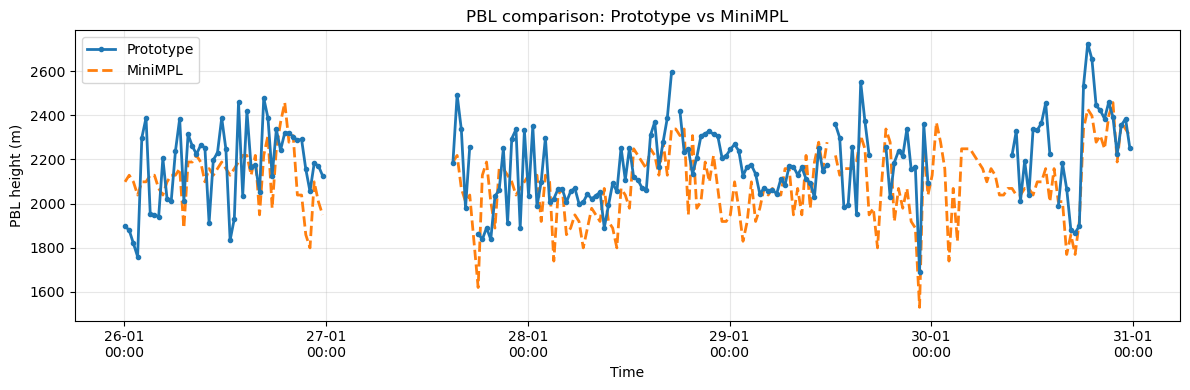

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_pbl_prototype_vs_minimpl(
    df_proto,
    df_mpl,
    *,
    proto_col="PBL_Prototype_m",   # ✅ update default if you renamed
    mpl_col="pbls_m",
    datetime_col_proto="timestamp",
    datetime_col_mpl="datetime",
    title="PBL comparison: Prototype vs MiniMPL",
    figsize=(12, 4),
):
    df_proto = df_proto.copy()
    df_mpl = df_mpl.copy()

    # ✅ force datetime dtype (fixes UnitData / tz error)
    df_proto[datetime_col_proto] = pd.to_datetime(df_proto[datetime_col_proto], errors="coerce")
    df_mpl[datetime_col_mpl] = pd.to_datetime(df_mpl[datetime_col_mpl], errors="coerce")

    df_proto = df_proto.dropna(subset=[datetime_col_proto]).sort_values(datetime_col_proto)
    df_mpl = df_mpl.dropna(subset=[datetime_col_mpl]).sort_values(datetime_col_mpl)

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(
        df_proto[datetime_col_proto],
        df_proto[proto_col],
        linestyle="-",
        linewidth=2,
        marker="o",
        markersize=3,
        label="Prototype",
        zorder=3,
    )

    ax.plot(
        df_mpl[datetime_col_mpl],
        df_mpl[mpl_col],
        linestyle="--",
        linewidth=2,
        label="MiniMPL",
        zorder=2,
    )

    ax.set_xlabel("Time")
    ax.set_ylabel("PBL height (m)")
    ax.set_title(title)

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%m\n%H:%M"))
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_pbl_prototype_vs_minimpl(
    df_proto=df_proto,
    df_mpl=MiniMPL_matched,
    proto_col="PBL_TR40_m",
    mpl_col="pbls_m",        # or "PBL_MPL_m"
    datetime_col_proto="datetime",
    datetime_col_mpl="datetime",
)


In [30]:
print("PROTO min/max:", df_proto["datetime"].min(), df_proto["timestamp"].max())
print("MPL   min/max:", MiniMPL_matched["datetime"].min(), MiniMPL_matched["datetime"].max())


PROTO min/max: 2026-01-26 00:05:00 23:35
MPL   min/max: 2026-01-26 00:05:00 2026-01-30 23:35:00


In [44]:
pbox_path = Path("/Users/thunthita/Lidarforiypnb/LIDar/RawFile/ALT-result-(26-30)-01-2026.csv")

PBox = pd.read_csv(pbox_path)
PBox

,Time,ALT from MPL,ALT Prototype,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,1/26/26 12:05 AM,2099.0,2074.0,NaN,NaN,NaN,NaN
1,1/26/26 12:35 AM,2129.0,2104.0,NaN,NaN,NaN,NaN
2,1/26/26 1:05 AM,2099.0,2070.0,NaN,NaN,NaN,NaN
3,1/26/26 1:35 AM,2039.0,2051.0,NaN,NaN,NaN,NaN
4,1/26/26 2:05 AM,2099.0,2074.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
235,NaN,NaN,NaN,NaN,NaN,NaN,NaN
236,NaN,NaN,NaN,NaN,NaN,NaN,NaN
237,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [76]:
PBox["datetime"] = pd.to_datetime(
    PBox["Time"],
    format="%m/%d/%y %I:%M %p",   # 👈 matches: 1/26/26 12:05 AM
    errors="coerce"
)
PBox.columns = (
    PBox.columns
        .str.strip()          # remove leading/trailing spaces
        .str.replace(" ", "_", regex=False)
)
PBox

,Time,ALT_from_MPL,ALT_Prototype,Unnamed:_3,Unnamed:_4,Unnamed:_5,Unnamed:_6,datetime
0,1/26/26 12:05 AM,2099.0,2074.0,NaN,NaN,NaN,NaN,2026-01-26 00:05:00
1,1/26/26 12:35 AM,2129.0,2104.0,NaN,NaN,NaN,NaN,2026-01-26 00:35:00
2,1/26/26 1:05 AM,2099.0,2070.0,NaN,NaN,NaN,NaN,2026-01-26 01:05:00
3,1/26/26 1:35 AM,2039.0,2051.0,NaN,NaN,NaN,NaN,2026-01-26 01:35:00
4,1/26/26 2:05 AM,2099.0,2074.0,NaN,NaN,NaN,NaN,2026-01-26 02:05:00
...,...,...,...,...,...,...,...,...
234,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
235,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
236,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
237,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT


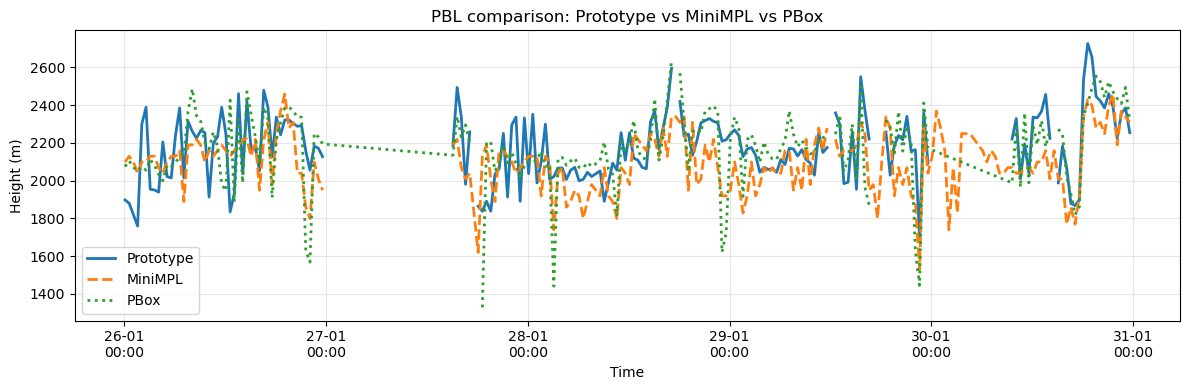

In [86]:
def plot_pbl_prototype_vs_minimpl(
    df_proto,
    df_mpl,
    *,
    df_pbox=None,                 # 👈 NEW
    proto_col="PBL_Prototype_m",
    mpl_col="pbls_m",
    pbox_col="ALT_Prototype",      # 👈 NEW
    datetime_col_proto="timestamp",
    datetime_col_mpl="datetime",
    datetime_col_pbox="timestamp",# 👈 NEW
    title="PBL comparison: Prototype vs MiniMPL vs PBox",
    figsize=(12, 4),
):

    df_proto = df_proto.copy()
    df_mpl = df_mpl.copy()

    df_proto[datetime_col_proto] = pd.to_datetime(df_proto[datetime_col_proto], errors="coerce")
    df_mpl[datetime_col_mpl] = pd.to_datetime(df_mpl[datetime_col_mpl], errors="coerce")

    df_proto = df_proto.dropna(subset=[datetime_col_proto]).sort_values(datetime_col_proto)
    df_mpl = df_mpl.dropna(subset=[datetime_col_mpl]).sort_values(datetime_col_mpl)

    fig, ax = plt.subplots(figsize=figsize)

    # Prototype
    ax.plot(
        df_proto[datetime_col_proto],
        df_proto[proto_col],
        label="Prototype",
        lw=2,
    )

    # MiniMPL
    ax.plot(
        df_mpl[datetime_col_mpl],
        df_mpl[mpl_col],
        "--",
        lw=2,
        label="MiniMPL",
    )

    # 👇 PBox (optional)
    if df_pbox is not None:
        df_pbox = df_pbox.copy()
        df_pbox[datetime_col_pbox] = pd.to_datetime(df_pbox[datetime_col_pbox], errors="coerce")
        df_pbox = df_pbox.dropna(subset=[datetime_col_pbox]).sort_values(datetime_col_pbox)

        ax.plot(
            df_pbox[datetime_col_pbox],
            df_pbox[pbox_col],
            ":",
            lw=2,
            label="PBox",
        )

    ax.set_xlabel("Time")
    ax.set_ylabel("Height (m)")
    ax.set_title(title)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%m\n%H:%M"))
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()
plot_pbl_prototype_vs_minimpl(
    df_proto=df_proto,
    df_mpl=MiniMPL_matched,
    df_pbox=PBox,                 # 👈 HERE
    proto_col="PBL_TR40_m",
    mpl_col="pbls_m",
    pbox_col="ALT_Prototype",
    datetime_col_proto="datetime",
    datetime_col_mpl="datetime",
    datetime_col_pbox="datetime",
)


In [84]:
print("PROTO:", df_proto["timestamp"].min(), "->", df_proto["timestamp"].max())
print("MPL  :", MiniMPL_matched["datetime"].min(), "->", MiniMPL_matched["datetime"].max())
print("PBox :", PBox["datetime"].min(), "->", PBox["datetime"].max())


PROTO: 00:05 -> 23:35
MPL  : 2026-01-26 00:05:00 -> 2026-01-30 23:35:00
PBox : 2026-01-26 00:05:00 -> 2026-01-30 23:35:00
